# Learn JupyterLab in 25 minutes 

## We want to learn jupyter

1. this is number 1
2. this is number 2
3. this is number 3

# this is test of keyboard shortcurt.

In [7]:
print('test')

test


In [5]:
print('Hello world')

Hello world!


# Import libraries

<Axes: xlabel='sepal_width', ylabel='sepal_length'>

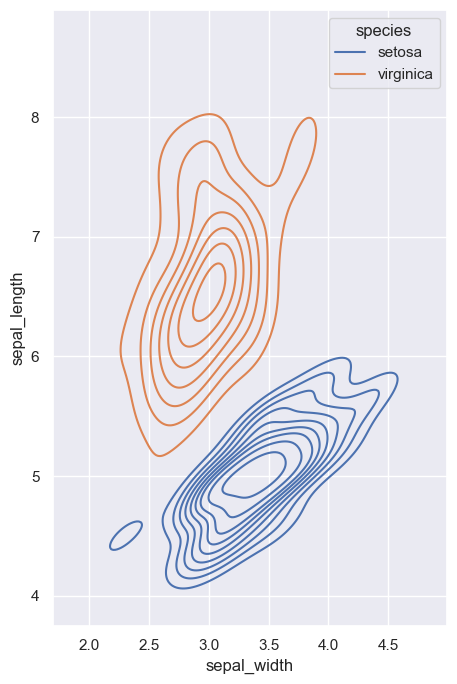

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="darkgrid")
iris = sns.load_dataset("iris")

# Set up the figure
f, ax = plt.subplots(figsize=(8, 8))
ax.set_aspect("equal")

# Draw a contour plot to represent each bivariate density
sns.kdeplot(
    data=iris.query("species != 'versicolor'"),
    x="sepal_width",
    y="sepal_length",
    hue="species",
    thresh=.1,
)

### This chart looks great.
**really great**

# Conclusion

write conclusion

In [ ]:
Voorbeeld decision tree met mutatie + methylatie

|--- methylatie_CDKN2A <= 0.28
|   |--- class: A
|--- methylatie_CDKN2A >  0.28
|   |--- methylatie_MGMT <= 0.25
|   |   |--- class: A
|   |--- methylatie_MGMT >  0.25
|   |   |--- class: B



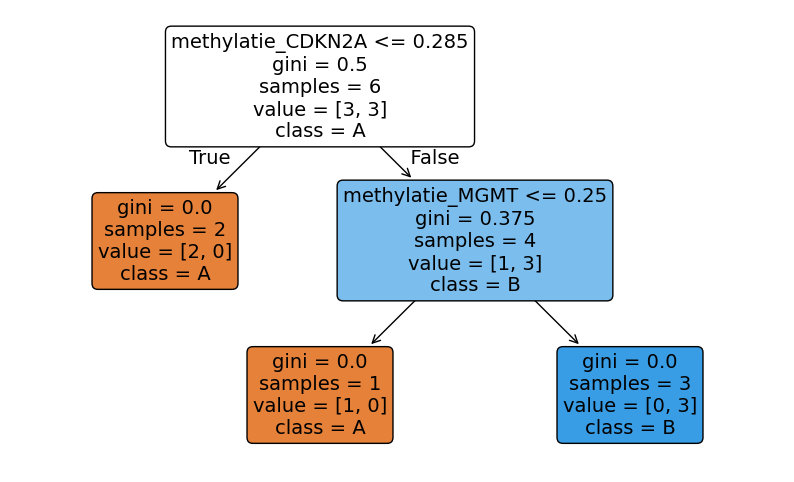

|--- methylatie_CDKN2A <= 0.28
|   |--- class: A
|--- methylatie_CDKN2A >  0.28
|   |--- methylatie_MGMT <= 0.25
|   |   |--- class: A
|   |--- methylatie_MGMT >  0.25
|   |   |--- class: B



In [3]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
import matplotlib.pyplot as plt


data = pd.DataFrame({
    'mutatie_BRCA1': [0, 1, 0, 1, 0, 1],
    'mutatie_TP53':  [1, 0, 0, 1, 1, 0],
    'methylatie_CDKN2A': [0.12, 0.35, 0.67, 0.22, 0.9, 0.6],
    'methylatie_MGMT':   [0.85, 0.42, 0.2, 0.75, 0.3, 0.55],
    'label': ['A', 'B', 'A', 'A', 'B', 'B']
})

X = data.drop(columns='label')
y = data['label']


clf = DecisionTreeClassifier(random_state=42, max_depth=3)
clf.fit(X, y)


print(export_text(clf, feature_names=list(X.columns)))

plt.figure(figsize=(10,6))
plot_tree(clf, 
          feature_names=X.columns,
          class_names=clf.classes_,
          filled=True, 
          rounded=True)
plt.show()

clf = DecisionTreeClassifier(random_state=42, max_depth=5)
clf.fit(X, y)

print(export_text(clf, feature_names=list(X.columns)))




|--- mutatie_BRCA1 <= 0.50
|   |--- mutatie_TP53 <= 0.50
|   |   |--- methylatie_MGMT <= 0.50
|   |   |   |--- class: A
|   |   |--- methylatie_MGMT >  0.50
|   |   |   |--- class: B
|   |--- mutatie_TP53 >  0.50
|   |   |--- class: A
|--- mutatie_BRCA1 >  0.50
|   |--- mutatie_TP53 <= 0.50
|   |   |--- class: B
|   |--- mutatie_TP53 >  0.50
|   |   |--- methylatie_CDKN2A <= 0.20
|   |   |   |--- class: B
|   |   |--- methylatie_CDKN2A >  0.20
|   |   |   |--- class: A



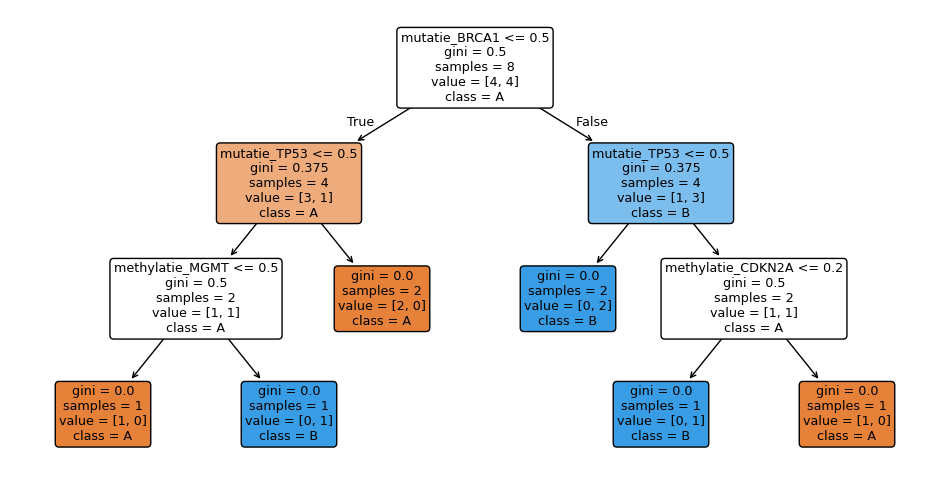

In [7]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
import matplotlib.pyplot as plt

# -----------------------------
# 1️⃣ Synthetische dataset
# -----------------------------
data = pd.DataFrame({
    'mutatie_BRCA1': [0, 1, 0, 1, 0, 1, 1, 0],
    'mutatie_TP53':  [1, 0, 0, 1, 1, 0, 1, 0],
    'methylatie_CDKN2A': [0.2, 0.4, 0.6, 0.1, 0.8, 0.5, 0.3, 0.7],
    'methylatie_MGMT':   [0.9, 0.3, 0.2, 0.7, 0.4, 0.6, 0.5, 0.8],
    # Labels afhankelijk van mutaties én methylaties
    'label': ['A', 'B', 'A', 'B', 'A', 'B', 'A', 'B']
})

X = data.drop(columns='label')
y = data['label']

# -----------------------------
# 2️⃣ Boom trainen
# -----------------------------
clf = DecisionTreeClassifier(random_state=42, max_depth=4)
clf.fit(X, y)

# -----------------------------
# 3️⃣ Tekstuele boom
# -----------------------------
print(export_text(clf, feature_names=list(X.columns)))

# -----------------------------
# 4️⃣ Visuele boom
# -----------------------------
plt.figure(figsize=(12,6))
plot_tree(clf, 
          feature_names=X.columns,
          class_names=clf.classes_,
          filled=True, 
          rounded=True)
plt.show()


|--- methylatie_CDKN2A <= 0.45
|   |--- methylatie_MGMT <= 0.80
|   |   |--- class: Resistant
|   |--- methylatie_MGMT >  0.80
|   |   |--- class: Responsive
|--- methylatie_CDKN2A >  0.45
|   |--- class: Responsive



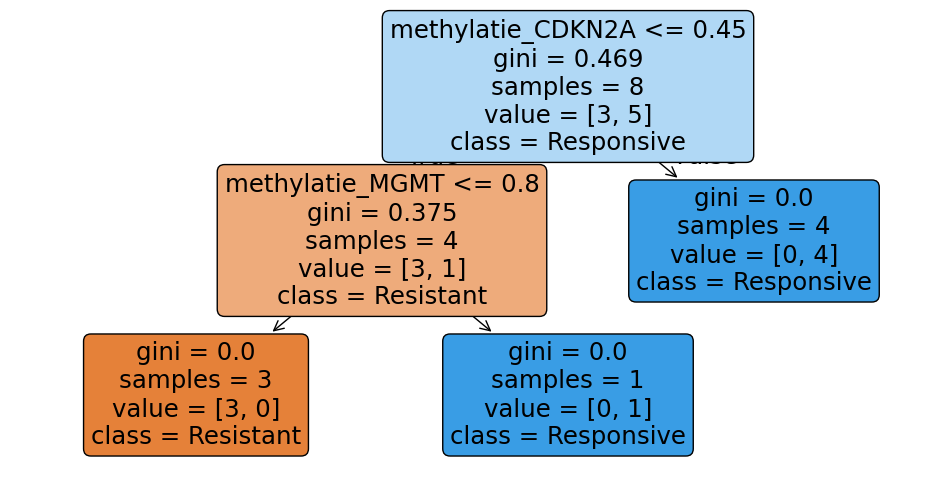

In [10]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
import matplotlib.pyplot as plt

# Kleine dataset met 2 mutaties en 2 methylaties
data = pd.DataFrame({
    'mutatie_BRCA1': [0, 1, 0, 1, 0, 1, 0, 1],
    'mutatie_TP53':  [1, 0, 0, 1, 1, 0, 1, 0],
    'methylatie_CDKN2A': [0.2, 0.4, 0.6, 0.1, 0.8, 0.5, 0.3, 0.7],
    'methylatie_MGMT':   [0.9, 0.3, 0.2, 0.7, 0.4, 0.6, 0.5, 0.8],
    # Labels afhankelijk van meerdere features
    'response': ['Responsive', 'Resistant', 'Responsive', 'Resistant',
                 'Responsive', 'Responsive', 'Resistant', 'Responsive']
})

X = data.drop(columns='response')
y = data['response']

# Train een iets diepere boom om meer splits te zien
clf = DecisionTreeClassifier(random_state=42, max_depth=4)
clf.fit(X, y)

# Tekstuele boom
print(export_text(clf, feature_names=list(X.columns)))

# Visuele boom
plt.figure(figsize=(12,6))
plot_tree(clf,
          feature_names=X.columns,
          class_names=clf.classes_,
          filled=True,
          rounded=True)
plt.show()
